# MLB line movement

**What this shows.** How a sportsbook's price on a single MLB game moves from the opener to the
close, expressed as an implied **win probability** curve. Books quote both sides with a margin
(the *vig*), so we de-vig the raw probabilities before plotting, then tabulate opener-vs-close.

**Quota cost.** ~200–300 records (one game's full line history plus a short recent-games listing).
Well under a ~10k budget.

> **Setup.** Install deps (`pip install -r requirements.txt` plus the editable SDK — see the
> [README](../README.md)) and export your key once:
>
> ```bash
> export STAT_API_KEY=sdb_xxxxxxxx_...
> ```
>
> The client reads `STAT_API_KEY` from the environment. To run against a local mirror instead of
> production, also set `STAT_API_BASE_URL` (e.g. `http://localhost:3399`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statapi import StatApi

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

api = StatApi()  # reads STAT_API_KEY (and STAT_API_BASE_URL if set)

# A recent, richly-lined final. `game_lines` is keyed by game — you always pass a
# game_id — so we name one here; the next cell shows how to browse recent finals.
GAME_ID = 162977

## 1 · Start from a game

`game_lines` requires a `game_id` filter — there is no "all lines" firehose. So you begin from a
game. Any final works; here are the most recent ones, and we use `GAME_ID` above (chosen for its
long snapshot history).

In [2]:
recent_finals = api.mlb.games.list(status="Final", limit=6)
pd.DataFrame(
    [(g["id"], g["game_time"][:10], g["away_team_id"], g["home_team_id"]) for g in recent_finals.rows],
    columns=["game_id", "date", "away_team_id", "home_team_id"],
)

,game_id,date,away_team_id,home_team_id
0,163665,2026-07-01,27,30
1,163666,2026-07-01,16,33
2,163667,2026-07-01,34,17
3,163664,2026-07-01,43,23
4,163663,2026-07-01,39,25
5,163662,2026-07-01,32,20


## 2 · Pull the full line history for the game

In [3]:
game = api.mlb.games.get(GAME_ID)
home = api.mlb.teams.get(game["home_team_id"])
away = api.mlb.teams.get(game["away_team_id"])
matchup = f"{away['abbreviation']} @ {home['abbreviation']}"
print(matchup, "on", game["game_time"][:10])

lines = list(api.mlb.game_lines.iter(game_id=GAME_ID))
df = pd.DataFrame(lines)
df["captured_at"] = pd.to_datetime(df["captured_at"])
df = df.sort_values("captured_at").reset_index(drop=True)
print(f"{len(df)} snapshots from {df['operator_id'].nunique()} book(s)")
df[["captured_at", "operator_id", "is_opening", "moneyline_home", "moneyline_away", "spread", "total",
    "implied_home_win_pct", "implied_away_win_pct"]].head()

CHC @ MIL on 2026-06-26
12 snapshots from 1 book(s)


,captured_at,operator_id,is_opening,moneyline_home,moneyline_away,spread,total,implied_home_win_pct,implied_away_win_pct
0,2026-06-26 16:40:02.210000+00:00,6,True,-267,215,1.5,7.0,0.7275,0.3175
1,2026-06-26 16:52:01.629000+00:00,6,False,-252,204,1.5,7.0,0.7159,0.3289
2,2026-06-26 17:04:01.591000+00:00,6,False,-245,198,1.5,7.0,0.7101,0.3356
3,2026-06-26 18:52:02.166000+00:00,6,False,-240,194,1.5,7.0,0.7059,0.3401
4,2026-06-26 19:22:02.032000+00:00,6,False,-245,198,1.5,7.0,0.7101,0.3356


## 3 · Implied win probability, de-vigged

A book's two prices sum to a little over 100% — the overround, or vig. Normalizing
`home / (home + away)` removes it, leaving a fair implied probability we can chart over time.

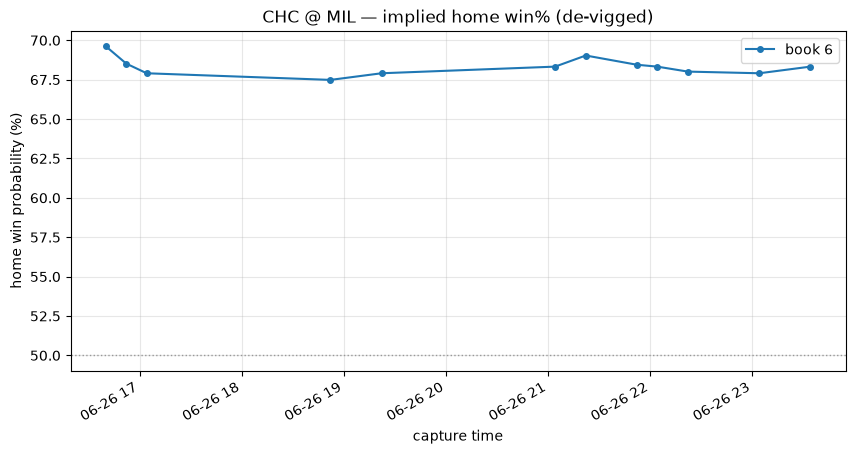

In [4]:
def devig_home(row):
    h, a = row["implied_home_win_pct"], row["implied_away_win_pct"]
    if h is None or a is None or (h + a) == 0:
        return None
    return 100 * h / (h + a)

df["home_wp"] = df.apply(devig_home, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for op_id, g in df.groupby("operator_id"):
    ax.plot(g["captured_at"], g["home_wp"], marker="o", ms=4, label=f"book {op_id}")
ax.axhline(50, color="#999", ls=":", lw=1)
ax.set_title(f"{matchup} — implied home win% (de-vigged)")
ax.set_ylabel("home win probability (%)")
ax.set_xlabel("capture time")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

## 4 · Opener vs close

In [5]:
rows = []
for op_id, g in df.groupby("operator_id"):
    g = g.sort_values("captured_at")
    opener = g[g["is_opening"]]
    opener = opener.iloc[0] if len(opener) else g.iloc[0]
    close = g.iloc[-1]
    rows.append({
        "book": op_id,
        "open_ml_home": opener["moneyline_home"],
        "close_ml_home": close["moneyline_home"],
        "open_home_wp%": round(opener["home_wp"], 1) if opener["home_wp"] is not None else None,
        "close_home_wp%": round(close["home_wp"], 1) if close["home_wp"] is not None else None,
        "open_total": opener["total"],
        "close_total": close["total"],
    })
movement = pd.DataFrame(rows)
movement["wp_move%"] = (movement["close_home_wp%"] - movement["open_home_wp%"]).round(1)
movement

,book,open_ml_home,close_ml_home,open_home_wp%,close_home_wp%,open_total,close_total,wp_move%
0,6,-267,-250,69.6,68.3,7.0,7.0,-1.3


## Quota used

In [6]:
q = api.mlb.game_lines.list(game_id=GAME_ID, limit=1).quota
print(f"Records remaining this month: {q.remaining:,} of {q.limit:,}")

Records remaining this month: 36,794 of 50,000
